# Objective

We want to fit a 1D problem in three ways 

1. Using the very basic SGD algorithms.
2. Using Gauss-Newton and Levenberg-Marquardt using exact Jacobians
3. Using the preconditioner to see we can replicate the success from 2.

Due to 3), we're constructing the preconditioner explicitly so 3) will be slow and only for a few types of networks. In particular, I have not done anything which allows for different layers/dimensions. Thus our network will be fairly restrictive; rather doing the usual like $R \to R^N \to R^N \cdots \to R$, we just do $R^N \to \cdots R^N$ where we just restrict the inputs and loss to only care about the first entries. This means a lot of the network will not be used. 

## Basic imports and setup

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


## Model Definition 

As discussed above, due to the explicit construction, we do something fairly odd. There's no classification layer at the end. We do use a residual structure, though this is not required. 

In [158]:
class MLP(nn.Module):
    num_units: int
    
    def setup(self):
        # self.dense1 = nn.Dense(self.num_units)
        # self.dense2 = nn.Dense(self.num_units)
        self.dense1 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
        self.dense2 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
    def __call__(self, x):
        f = self.dense1(x)
        f = nn.tanh(f)
        f = self.dense2(f)
        return f + x 
    

class SimpleMLP(nn.Module):
    """
    We ONLY work with "MLP" layers from above; see setup()

    Use sow to save intermediates for computation of preconditioner
    """
    num_layers: int
    num_units: int
    num_classes: int

    def setup(self):
        # Create a list of Dense layers
        self.layers = (
            *[
                MLP(self.num_units, name=f"layer_{i:02}") for i in range(self.num_layers - 1)
            ], 
            MLP(self.num_units, name=f"layer_{self.num_layers-1:02}") # For now, do all the same dimensions 
        )
        
    def __call__(self, x):
        # Store input to match the notes
        self.sow('intermediates',  f'layer_{0}_output', x)
        
        # Pass the input through each layer
        for i, layer in enumerate(self.layers):
            x = layer(x)
            
            # Store input to match the notes
            self.sow('intermediates', f'layer_{i+1}_output', x)
            
        return x


## Constant and Data Generation 

We generate 1D data without noise and set some constants regarding the model which is uniform among all the tests such as layers and dimensions. 

For sake of computation time, we only do very few amounts of points! 

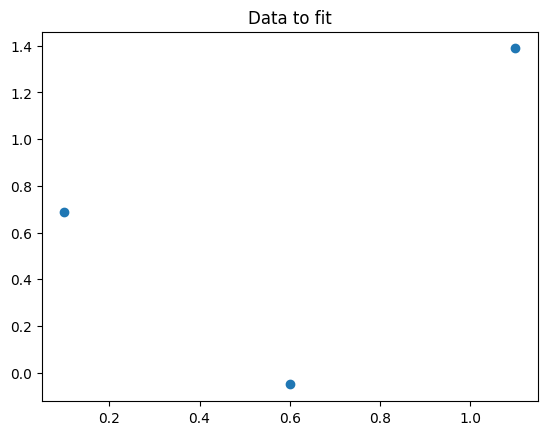

In [242]:
# Model definition 
L = 10 # We use 10 Layers for full runs, 3 layers to debug
n = 1 # e.g. 5 total dimensions, to reflect the data R^5 \to R^5 

num_samples = 3
# X = jax.random.uniform(jax.random.PRNGKey(0), (num_samples, 1), minval=0, maxval=1)
X = jnp.linspace(0, 1, num_samples).reshape((-1, 1)) + .1
y = jnp.sin(2 * jnp.pi * X) + jnp.tanh(X)

plt.scatter(X, y)
plt.title('Data to fit')
plt.show()
zeros_to_append = jnp.zeros((num_samples, n-1))

# Concatenate the original array and the zeros array along axis 1 (columns)
X = jnp.concatenate((X, zeros_to_append), axis=1)
y = jnp.concatenate((y, zeros_to_append), axis=1)
treescope.display((X, y))



## First, train using standard 

We just use SGD/Adam. This way, we have a baseline for at least baseline performance of the algorithms. 

In [245]:
def train_model_sgd(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions[:, 0] - batch_y[:, 0]))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)
        state = state.apply_gradients(grads=grads)
        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        losses.append(loss)

    return state, losses

num_epochs = 5_000

key = jax.random.PRNGKey(0)

model = SimpleMLP(num_layers=L, num_units=n, num_classes=n)
params = model.init(key, jnp.ones((1, n)))['params']

# Train the model
trained_state_sgd, sgd_losses = train_model_sgd(
    X, y, model, params, learning_rate=2e-3, num_epochs=num_epochs
)

Starting training for 5000 epochs...


  0%|          | 0/5000 [00:00<?, ?it/s]

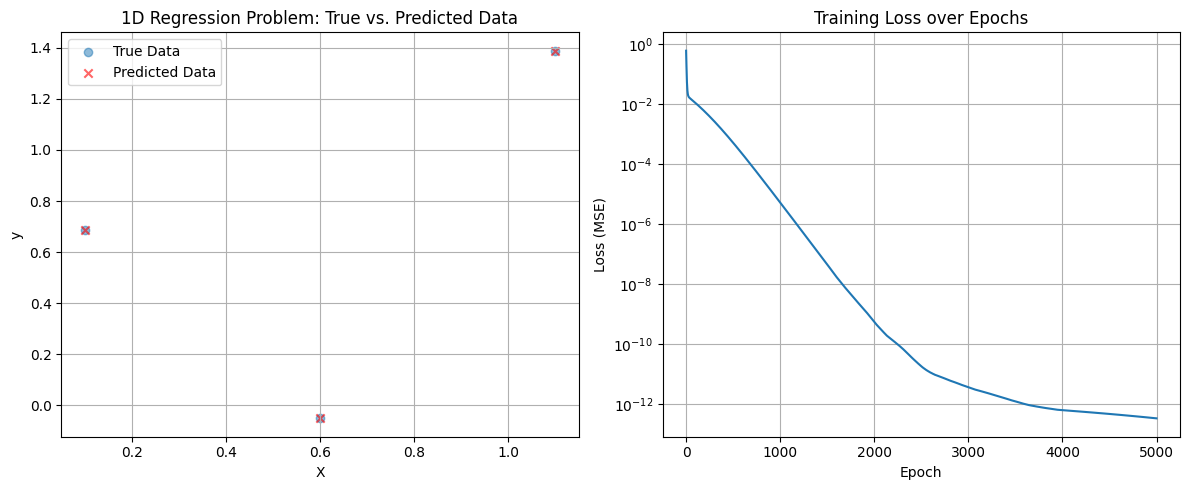

In [246]:
predicted_y = model.apply({'params': trained_state_sgd.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X[:, 0], y[:, 0], marker='o', label='True Data', alpha=0.5)
plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
plt.semilogy(sgd_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()

## Preconditioned

Now we do a preconditioned method; we're NOT caring about speed here, so we explicitly construct the Jacobian and all that. 

In [248]:
def train_model_precond(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions[:, 0] - batch_y[:, 0]))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Explicitly construct Jacobian 
        jacobian = jax.jacobian(state.apply_fn, argnums=0)({'params': params}, X)
        flattened, _ = jax.tree.flatten(jacobian)
        reshaped_leaves = [leaf.reshape(batch_X.shape[0], n, -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        jacobian = aggregated_array.reshape((batch_X.shape[0] * batch_X.shape[1], -1))
        
        # Explicitly construct the Jacobian
        # jacobian_fn = jax.jacrev(state.apply_fn)({'params': params}, X)
        # flat_jacobian = []
        # for layer in jacobian_fn['params'].values():
        #     for dense in layer.values():  # This is specific for the above architecture... not very extendable yet
        #         for param in dense.values(): 
        #             flat_jacobian.append(
        #                 param.reshape((batch_X.shape[0] * batch_X.shape[1], -1))
        #             )
        #     # jacobian_fn
        # jacobian = jnp.concatenate(flat_jacobian, axis=1)

        jtj = jacobian.T @ jacobian

        lm_mat = 1e-1 * jnp.eye(jtj.shape[0]) + jtj
        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = jnp.linalg.solve(lm_mat, flattened) # Solve directly 
        grads = back(altered) # Convert vector back to PyTree
        
        state = state.apply_gradients(grads=grads)
        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)

    return state, losses

num_epochs = 5_000

key = jax.random.PRNGKey(0)

model = SimpleMLP(num_layers=L, num_units=n, num_classes=n)
params = model.init(key, jnp.ones((1, n)))['params']

# Train the model
trained_state_precond, precond_losses = train_model_precond(
    X, y, model, params, learning_rate=3e-4, num_epochs=num_epochs
)

Starting training for 5000 epochs...


  0%|          | 0/5000 [00:00<?, ?it/s]

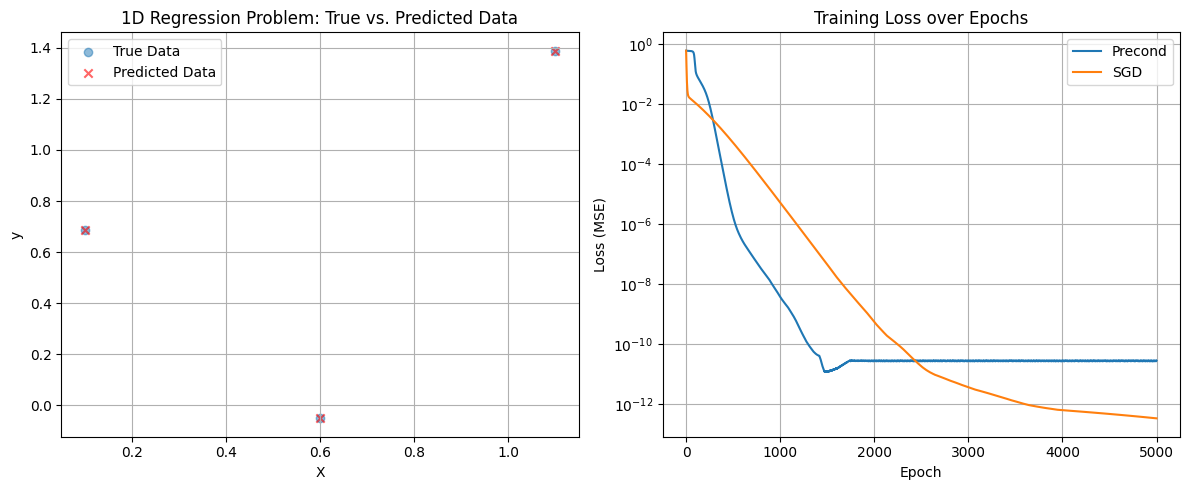

In [249]:
predicted_y = model.apply({'params': trained_state_precond.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X[:, 0], y[:, 0], marker='o', label='True Data', alpha=0.5)
plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
plt.semilogy(precond_losses, label='Precond')
plt.semilogy(sgd_losses, label='SGD')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()

## Finally, move to inexact Jacobian

In each iteration, we have to look construct the inexact thing, which ... can be slow. We first have to build a bit of framework and try to speed up the computation. 

My old code had a lot of loops, we take a bit of time to first take out *some* of the loops. 

### First copy over over the construction from before, trying to make it more efficient

In [250]:
import numpy as np

In [251]:
# Create layer model; then be able to take the gradients and stuff
layer = MLP(num_units=n)

# First define function
def apply_layer(params, x): 
    # assert len(x) == 1
    # return jnp.squeeze(layer.apply(params, x))
    return layer.apply(params, x)

K_i = jax.jit(jax.jacrev(apply_layer, argnums=0))
M_i = jax.jit(jax.jacrev(apply_layer, argnums=1))


In [252]:
# We run a sample just to be able to time first
predictions, intermediates = model.apply({'params':params}, X, mutable=['intermediates'])
n_samples = len(X)


In [255]:
# %%timeit # Original way
# Initialize dgdu as a tridiagonal matrix with ones down the diagonal
true_dgdu = np.eye(n_samples * n * (L + 1)) # It's tridiagonal with ones down diagonal; will have to change once scaled up
counter = 0
for l in range(L):
    vals = -jnp.squeeze(M_i({'params': params[f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0]))

    # vals
    for s in range(n_samples):
        for t in range(n):
            for u in range(n): 
                # true_dgdu[counter * (n_samples * n) + s * n + t, 
                     # counter * (n_samples * n) + (n_samples * n) + s * n + u] =  vals[s, u, s, t]
                true_dgdu[counter * (n_samples * n) + s * n + t, 
                     counter * (n_samples * n) + (n_samples * n) + s * n + u] =  vals[s, s]
                # true_dgdu[counter * (n_samples * n) + s * n + t, 
                     # counter * (n_samples * n) + (n_samples * n) + s * n + u] =  vals

    counter += 1
# true_dgdu.T[0:60, 0:60]

In [256]:
# %%timeit # Slightly better
# Initialize dgdu as a tridiagonal matrix with ones down the diagonal
dgdu = np.eye(n_samples * n * (L + 1)) # It's tridiagonal with ones down diagonal; will have to change once scaled up
counter = 0
for l in range(L):
    vals = -jnp.squeeze(M_i({'params': params[f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0]))

    # vals
    for s in range(n_samples):
        # dgdu[counter * (n_samples * n) + s * n:counter * (n_samples * n) + s * n + n, 
        #      counter * (n_samples * n) + (n_samples * n) + s * n:counter * (n_samples * n) + (n_samples * n) + s * n + n] \
        #         =  vals[s, :, s, :].T
        dgdu[counter * (n_samples * n) + s * n:counter * (n_samples * n) + s * n + n, 
             counter * (n_samples * n) + (n_samples * n) + s * n:counter * (n_samples * n) + (n_samples * n) + s * n + n] \
                =  vals[s, s].T
        # dgdu[counter * (n_samples * n) + s * n:counter * (n_samples * n) + s * n + n, 
        #      counter * (n_samples * n) + (n_samples * n) + s * n:counter * (n_samples * n) + (n_samples * n) + s * n + n] \
        #         =  vals


    counter += 1

assert np.linalg.norm(dgdu - true_dgdu) < 1e-12

In [258]:
true_dgdu

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(33, 33))

In [259]:
# %%timeit

# Number of trainable parameters
p = sum(x.size for x in jax.tree.leaves(params))
dgdt_true = np.zeros((p, n_samples * n * (L + 1)))
counter = 0
for l in range(L): 
    flattened, _ = jax.tree.flatten(
            K_i({'params': params[f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0])
    )
    
    # Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
    reshaped_leaves = [leaf.reshape(n_samples, n, -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    
    layer_p = aggregated_array.shape[-1]

    for s in range(n_samples):
        for t in range(n):
            dgdt_true[counter:counter + layer_p, 
                 n_samples * n * l + n_samples * n + s * n + t] =  aggregated_array[s, t]
    counter += layer_p
    
# dgdt_true

In [260]:
# %%timeit
# Number of trainable parameters

dgdt = np.zeros((p, n_samples * n * (L + 1)))
counter = 0
for l in range(L): 
    flattened, _ = jax.tree.flatten(
            K_i({'params': params[f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0])
    )
    
    # Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
    reshaped_leaves = [leaf.reshape(n_samples, n, -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    
    layer_p = aggregated_array.shape[-1]

    for s in range(n_samples):
        dgdt[counter:counter + layer_p, 
            n_samples * n * l + n_samples * n + s * n:n_samples * n * l + n_samples * n + s * n + n] = aggregated_array[s, :].T
    counter += layer_p
    
assert np.linalg.norm(dgdt - dgdt_true) < 1e-12

In [261]:
dgdt.T

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.06919268,
         1.        , -0.25125936],
       [ 0.        ,  0.        ,  0.        , ..., -0.0457566 ,
         1.        ,  0.16609427],
       [ 0.        ,  0.        ,  0.        , ..., -0.12003285,
         1.        ,  0.52668709]], shape=(33, 40))

In [262]:
def partition_with_overlap(L, N):
    # Compute the approximate size of each partition
    step = L / N
    
    # Generate the partition points
    c = [round(i * step) for i in range(N + 1)]
    
    return c

def make_matrices(L, ND): 
    """
    Given L layers and ND blocks, give the restriction, pou and q matrices for testing
    """
    restrictions = []
    pous = []
    qs = []

    cs = partition_with_overlap(L, ND)
    for d in range(ND): 
        time_steps = cs[d + 1] - cs[d] + 1
        r = np.zeros((n_samples * n * time_steps, n_samples * n * (L + 1)))
        for t in range(n_samples * n * time_steps):
            r[t, n_samples * n * cs[d] + t] = 1

        pou = np.eye(n_samples * n * time_steps)
        if d == 0:
            pou[np.arange(len(pou) - n_samples * n, len(pou)), np.arange(len(pou) - n_samples * n, len(pou))] = 0.5
        elif d == ND - 1:
            pou[np.arange(0, n_samples * n), np.arange(0, n_samples* n)] = 0.5
        else: 
            pou[np.arange(0, n_samples * n), np.arange(0, n_samples* n)] = 0.5
            pou[np.arange(len(pou) - n_samples* n, len(pou)), np.arange(len(pou) - n_samples* n, len(pou))] = 0.5

        if d == 0:
            q = np.zeros((n_samples* n * time_steps, n_samples* n * (L + 1)))
            for i in range(n_samples* n * time_steps): 
                q[i, i] = 1
        else:
            q = np.zeros((n_samples* n * (time_steps + 1), n_samples* n *( L + 1)))
            for t in range(n_samples* n * (time_steps + 1)): 
                q[t, n_samples* n * cs[d] - n_samples* n + t] = 1
        
        restrictions.append(r)
        pous.append(pou)
        qs.append(q)

    # assert np.linalg.norm(R1.T @ D1 @ R1 + R2.T @ D2 @ R2 + R3.T @ D3 @ R3 - np.eye(10)) < 1e-10

    return restrictions, pous, qs


In [263]:
ND = 3
# make_matrices(L, ND)

## Let us look at the preconditioner again; and how it works with the Jacobian

I currently don't have the coarse space built in. We can do a little live codign if needed. 

In [264]:
restrictions, pous, qs = make_matrices(L, ND)
# Construct RAS preconditioner 
ras = np.zeros((n_samples * n * (L + 1), n_samples * n * (L + 1)))
for i in range(ND): 
    R = restrictions[i]
    D = pous[i]
    ras += R.T @ D @ jnp.linalg.inv(R @ dgdu.T @ dgdu @ R.T) @ R
    # print(i)

rasq = np.zeros((n_samples * n * (L + 1), n_samples * n * (L + 1)))
for i in range(ND): 
    R = restrictions[i]
    D = pous[i]
    Q = qs[i]
    Js = np.linalg.inv(Q @ dgdu @ Q.T)
    rasq += R.T @ D @ (R @ Q.T @ Js @ Js.T @ Q @ R.T) @ R

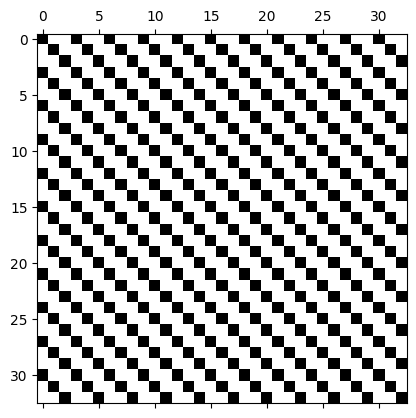

In [265]:
plt.spy(np.linalg.inv(dgdu.T @ dgdu))

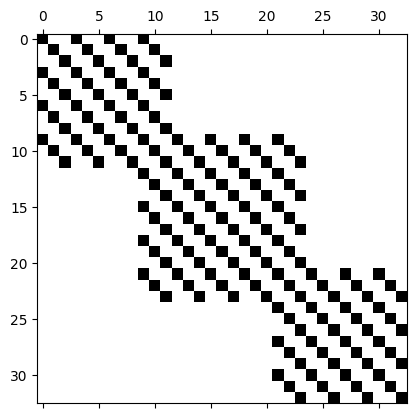

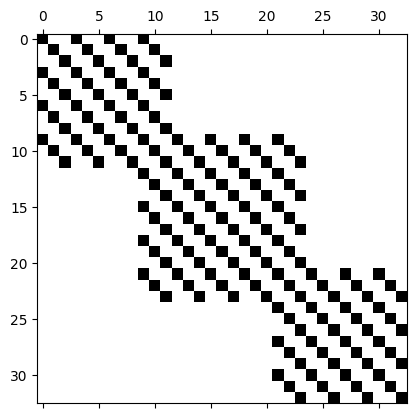

In [266]:
plt.spy(ras)
plt.show()
plt.spy(rasq)

Let's look at the Jacobian of the network calculated normally, and with the preconditioner

In [267]:
params

{'layer_00': {'dense1': {'kernel': <jax.Array([[-1.5057027]], dtype=float32)>,
   'bias': <jax.Array([0.00563218], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[-0.73806745]], dtype=float32)>,
   'bias': <jax.Array([0.02606239], dtype=float32)>}},
 'layer_01': {'dense1': {'kernel': <jax.Array([[-0.4199463]], dtype=float32)>,
   'bias': <jax.Array([-0.00496414], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[0.9462289]], dtype=float32)>,
   'bias': <jax.Array([-0.01052106], dtype=float32)>}},
 'layer_02': {'dense1': {'kernel': <jax.Array([[-2.0070188]], dtype=float32)>,
   'bias': <jax.Array([0.00379716], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[-0.19703926]], dtype=float32)>,
   'bias': <jax.Array([0.00040974], dtype=float32)>}},
 'layer_03': {'dense1': {'kernel': <jax.Array([[1.5657363]], dtype=float32)>,
   'bias': <jax.Array([0.01429557], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[2.067297]], dtype=float32)>,
   'bias': <jax.Array([-0.00271632], dtype=float32)>}},
 'layer_04': {'dense1': {'kernel': <jax.Array([[0.29392666]], dtype=float32)>,
   'bias': <jax.Array([0.00469606], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[-1.720078]], dtype=float32)>,
   'bias': <jax.Array([-0.00299669], dtype=float32)>}},
 'layer_05': {'dense1': {'kernel': <jax.Array([[1.2105913]], dtype=float32)>,
   'bias': <jax.Array([-0.00573244], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[-1.4879638]], dtype=float32)>,
   'bias': <jax.Array([0.01531608], dtype=float32)>}},
 'layer_06': {'dense1': {'kernel': <jax.Array([[-0.79896164]], dtype=float32)>,
   'bias': <jax.Array([-0.0040034], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[-0.43717903]], dtype=float32)>,
   'bias': <jax.Array([-0.00604072], dtype=float32)>}},
 'layer_07': {'dense1': {'kernel': <jax.Array([[-0.00248698]], dtype=float32)>,
   'bias': <jax.Array([0.00336052], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[0.21718332]], dtype=float32)>,
   'bias': <jax.Array([-0.01402313], dtype=float32)>}},
 'layer_08': {'dense1': {'kernel': <jax.Array([[-1.2945387]], dtype=float32)>,
   'bias': <jax.Array([-0.00226609], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[-0.7123804]], dtype=float32)>,
   'bias': <jax.Array([-0.00036719], dtype=float32)>}},
 'layer_09': {'dense1': {'kernel': <jax.Array([[0.42490306]], dtype=float32)>,
   'bias': <jax.Array([0.00248147], dtype=float32)>},
  'dense2': {'kernel': <jax.Array([[-0.12105215]], dtype=float32)>,
   'bias': <jax.Array([-0.00584224], dtype=float32)>}}}

In [268]:
# Regular way
jacobian = jax.jacobian(model.apply, argnums=0)({'params': params}, X)

flattened, _ = jax.tree.flatten(jacobian)
reshaped_leaves = [leaf.reshape(n_samples, n, -1) for leaf in flattened]
aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
jacobian = aggregated_array.reshape((X.shape[0] * X.shape[1], -1))
treescope.display(jacobian)

# plt.spy(jacobian)
plt.show()
jtj = jacobian.T @ jacobian
# plt.spy(jtj)
treescope.display(jtj)

In [269]:
np.linalg.inv(dgdu.T)

array([[ 1.        , -0.        , -0.        , ..., -0.        ,
        -0.        , -0.        ],
       [-0.        ,  1.        , -0.        , ..., -0.        ,
        -0.        , -0.        ],
       [-0.        , -0.        ,  1.        , ..., -0.        ,
        -0.        , -0.        ],
       ...,
       [-4.065141  , -0.        , -0.        , ...,  1.        ,
        -0.        , -0.        ],
       [ 0.        ,  2.77980811,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.        ,  0.        ,  1.2982947 , ...,  0.        ,
         0.        ,  1.        ]], shape=(33, 33))

In [270]:
np.linalg.inv(dgdu.T) @ dgdt[0:4, :].T

array([[ 3.84259341e-17,  3.84259325e-18, -5.31642698e-17,
         7.65202066e-18],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-7.22777426e-01, -7.22777396e-02,  1.00000000e+00,
        -1.43931642e-01],
       [-3.60516876e-01, -2.16310129e-01,  1.00000000e+00,
        -7.15219796e-01],
       [-1.01159707e-01, -1.11275680e-01,  1.00000000e+00,
        -9.28945482e-01],
       [-4.38568050e-01, -4.38568032e-02,  6.06781610e-01,
        -8.73350736e-02],
       [-2.46770038e-01, -1.48062025e-01,  6.84489560e-01,
        -4.89560483e-01],
       [-7.76577822e-02, -8.54235627e-02,  7.67675043e-01,
        -7.13128263e-01],
       [-6.01816034e-01, -6.01816010e-02,  8.32643650e-01,
        -1.19843768e-01],
       [-2.66799662e-01, -1.60079799e-01,  7.40047636e-01,
        -5.29296719e-01],
       [-7.86775234e-02, -8.65452781e-02,  7.77755551e-01,
        -7.22492505e-01],
       [-2.39916499e+00, -2.39916489e-01,  3.31936900e+00,
        -4.77762232e-01],
       [-4.50888406e-01, -2.70533047e-01,  1.25067212e+00,
        -8.94505459e-01],
       [-9.12785822e-02, -1.00406443e-01,  9.02321539e-01,
        -8.38207516e-01],
       [-1.24498270e+00, -1.24498265e-01,  1.72249804e+00,
        -2.47921971e-01],
       [-3.24206669e-01, -1.94524004e-01,  8.99282919e-01,
        -6.43184946e-01],
       [-7.20019084e-02, -7.92021013e-02,  7.11764701e-01,
        -6.61190603e-01],
       [ 6.22091336e-01,  6.22091311e-02, -8.60695580e-01,
         1.23881328e-01],
       [-2.73904470e-01, -1.64342684e-01,  7.59754919e-01,
        -5.43391758e-01],
       [-6.86575986e-02, -7.55233604e-02,  6.78704998e-01,
        -6.30479942e-01],
       [ 8.32521010e-01,  8.32520976e-02, -1.15183593e+00,
         1.65785637e-01],
       [-3.67843666e-01, -2.20706202e-01,  1.02032301e+00,
        -7.29755218e-01],
       [-8.73976264e-02, -9.61373916e-02,  8.63956898e-01,
        -8.02568857e-01],
       [ 8.32071348e-01,  8.32071313e-02, -1.15121380e+00,
         1.65696093e-01],
       [-3.67644983e-01, -2.20586993e-01,  1.01977191e+00,
        -7.29361058e-01],
       [-8.73504203e-02, -9.60854649e-02,  8.63490249e-01,
        -8.02135365e-01],
       [ 1.47821891e+00,  1.47821885e-01, -2.04519242e+00,
         2.94367903e-01],
       [-6.83763495e-01, -4.10258103e-01,  1.89661994e+00,
        -1.35650012e+00],
       [-1.18374524e-01, -1.30211979e-01,  1.17017464e+00,
        -1.08702845e+00],
       [ 1.40698613e+00,  1.40698608e-01, -1.94663818e+00,
         2.80182830e-01],
       [-6.49564061e-01, -3.89738442e-01,  1.80175771e+00,
        -1.28865278e+00],
       [-1.13974865e-01, -1.25372354e-01,  1.12668243e+00,
        -1.04662656e+00]])

In [271]:
# Using the "layer formulation" dg/du^(-1) dg/dt 
derivative = np.linalg.inv(dgdu.T) @ dgdt.T
# plt.spy(derivative[-n_samples * n:, :])
# plt.show()
treescope.display(derivative)
# plt.spy(derivative[-n_samples * n:, :].T @ derivative[-n_samples * n:, :] )
np.linalg.norm(derivative[-n_samples * n:, :].T @ derivative[-n_samples * n:, :]  - jtj) / np.linalg.norm(jtj) # This is probably ill-conditioned

np.float64(4.6666489828658344e-08)

In [272]:
# Using the "layer formulation" dg/du^(-1) dg/dt 
derivative = (np.linalg.inv(dgdu.T) @ dgdt.T)[-n_samples * n:, :] 
treescope.display(derivative)
# plt.spy(derivative[-n_samples * n:, :].T @ derivative[-n_samples * n:, :] )
np.linalg.norm(derivative.T @ derivative  - jtj) / np.linalg.norm(jtj) # This is probably ill-conditioned

np.float64(4.6666489828658344e-08)

In [291]:
E = np.zeros((n_samples, n_samples * (L + 1)))
for i in range(n_samples):
    E[-i-1, -i-1] = 1
E @ (np.linalg.inv(dgdu.T) @ dgdt.T) - jacobian

<jax.Array float64(3, 40) ≈4.4e-10 ±3.4e-08 [≥-1.2e-07, ≤1e-07] zero:12 nonzero:108
  <Arrayviz rendering>
| Device: GPU 0>

In [292]:
np.linalg.eigvalsh( np.linalg.inv(dgdu) @ E.T @ E @ (np.linalg.inv(dgdu.T)))

array([-7.07028929e-15, -5.85763378e-15, -5.51080960e-15, -4.37966786e-15,
       -3.15314519e-15, -2.25010744e-15, -2.05465774e-15, -1.76167119e-15,
       -1.63205561e-15, -8.22775911e-16, -6.12950566e-16, -3.70094707e-16,
       -1.45019180e-16, -7.12610646e-17,  9.08598983e-18,  3.16955486e-16,
        4.76044448e-16,  7.18093192e-16,  8.52308055e-16,  1.21083081e-15,
        1.34466294e-15,  1.65974725e-15,  1.95232380e-15,  2.66280538e-15,
        2.87821295e-15,  4.10069677e-15,  4.63124480e-15,  4.79128042e-15,
        6.94835522e-15,  1.08277407e-14,  1.93583357e+01,  4.36860748e+01,
        5.04305389e+01])

In [293]:
np.linalg.eigvalsh( np.linalg.inv(dgdu) @ (np.linalg.inv(dgdu.T)))

array([5.56481786e-02, 1.59489923e-01, 1.74405465e-01, 1.83195531e-01,
       1.95479903e-01, 2.25448279e-01, 2.34161898e-01, 2.55200449e-01,
       2.58748679e-01, 2.67738340e-01, 2.77019266e-01, 3.13533051e-01,
       3.42836445e-01, 4.26259910e-01, 4.32857058e-01, 5.09448545e-01,
       5.26959722e-01, 5.31077515e-01, 6.12198773e-01, 6.79274058e-01,
       6.92824042e-01, 1.29287902e+00, 1.30206625e+00, 1.31414398e+00,
       2.09534861e+00, 2.34274153e+00, 2.79076051e+00, 6.63645322e+00,
       8.61450503e+00, 1.85127203e+01, 7.02374807e+01, 1.39344636e+02,
       2.72820571e+02])

In [295]:
E = np.zeros((n_samples, n_samples * (L + 1)))
for i in range(n_samples):
    E[-i-1, -i-1] = 1

# derivative = (E @ (np.linalg.inv(dgdu.T) @ dgdt.T)).T @ E @ (np.linalg.inv(dgdu.T) @ dgdt.T)
derivative = dgdt @ np.linalg.inv(dgdu) @ E.T @ E @ (np.linalg.inv(dgdu.T) @ dgdt.T)


derivative - jtj

<jax.Array float64(40, 40) ≈7.2e-09 ±1.9e-07 [≥-1.3e-06, ≤1.7e-06] zero:3 nonzero:1_597
  <Arrayviz rendering>
| Device: GPU 0>

In [296]:
np.linalg.inv(dgdu) @ E.T @ E @ (np.linalg.inv(dgdu.T))

array([[16.52537135,  0.        ,  0.        , ..., -4.065141  ,
         0.        ,  0.        ],
       [ 0.        ,  7.72733314,  0.        , ...,  0.        ,
         2.77980811,  0.        ],
       [ 0.        ,  0.        ,  1.68556913, ...,  0.        ,
         0.        ,  1.2982947 ],
       ...,
       [-4.065141  ,  0.        ,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.        ,  2.77980811,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.        ,  0.        ,  1.2982947 , ...,  0.        ,
         0.        ,  1.        ]], shape=(33, 33))

In [297]:
np.linalg.inv(dgdu) @ (np.linalg.inv(dgdu.T))

array([[120.54103315,   0.        ,   0.        , ...,  -4.065141  ,
          0.        ,   0.        ],
       [  0.        ,  34.06467927,   0.        , ...,   0.        ,
          2.77980811,   0.        ],
       [  0.        ,   0.        ,  11.76397521, ...,   0.        ,
          0.        ,   1.2982947 ],
       ...,
       [ -4.065141  ,   0.        ,   0.        , ...,   1.        ,
          0.        ,   0.        ],
       [  0.        ,   2.77980811,   0.        , ...,   0.        ,
          1.        ,   0.        ],
       [  0.        ,   0.        ,   1.2982947 , ...,   0.        ,
          0.        ,   1.        ]], shape=(33, 33))

In [298]:
derivative = dgdt @ np.linalg.inv(dgdu)@ (np.linalg.inv(dgdu.T) @ dgdt.T)

In [299]:
# hessian_fn = jax.hessian(model.apply, argnums=0)
# hessian = hessian_fn({'params': params}, X)

In [300]:
# from jax.flatten_util import ravel_pytree

# flat_hessian, _ = ravel_pytree(hessian)
# flat_hessian = flat_hessian.reshape((80, 80))
# print(flat_hessian.shape)

In [301]:
# np.linalg.eigvalsh(flat_hessian)

In [302]:
derivative = dgdt @ np.linalg.inv(dgdu) @ (np.linalg.inv(dgdu.T) @ dgdt.T)
np.linalg.eigvalsh(derivative)

array([-3.14489207e-14, -1.28271992e-14, -7.12625412e-15, -1.06528405e-15,
       -2.24585216e-16, -1.56021429e-17,  4.59643307e-16,  4.54300776e-15,
        2.33542170e-14,  3.03637659e-14,  6.11154468e-14,  1.27303372e-04,
        1.74583648e-04,  5.41051261e-04,  3.20077624e-03,  4.53830220e-03,
        9.05607492e-03,  1.45362353e-02,  1.78764081e-02,  3.10529913e-02,
        5.35823146e-02,  1.17494146e-01,  1.47665970e-01,  2.04888824e-01,
        4.05044711e-01,  4.74275300e-01,  6.81187398e-01,  8.41839956e-01,
        9.44247884e-01,  1.05422992e+00,  1.54670329e+00,  1.86683847e+00,
        2.29142882e+00,  2.65976728e+00,  4.38368996e+00,  5.24468566e+00,
        1.21234229e+01,  4.00966862e+01,  1.84862975e+02,  5.86905471e+02])

In [303]:
np.linalg.eigvalsh(jtj)
jtj

<jax.Array float32(40, 40) ≈0.17 ±4.0 [≥-2.4e+01, ≤4.4e+01] nonzero:1_600
  <Arrayviz rendering>
| Device: GPU 0>

In [304]:
# Finally; let's look at the preconditioned version 
# plt.spy(dgdt @ (rasq @ dgdt.T))
# plt.show()
treescope.display(dgdt @ (ras @ dgdt.T))


### Training

From the above, without the coarse space, since the Jacobian is at the "end" of the time; the preconditioner is only partial in some sense? 

We can train for a bit to see what happens

In [305]:
def train_model_inexact(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    n_samples = X_train.shape[0]

    # Make the inexact restriction and prolongation
    restrictions, pous, qs = make_matrices(L, ND)

    # @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions[:, 0] - batch_y[:, 0]))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Construct dg/dt and dg/du 
        p = sum(x.size for x in jax.tree.leaves(params))

        dgdu = jnp.eye(n_samples * n * (L + 1)) # It's tridiagonal with ones down diagonal; will have to change once scaled up
        counter = 0
        for l in range(L):
            vals = -jnp.squeeze(M_i({'params': params[f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0]))
        
            # vals
            for s in range(n_samples):
                # dgdu = dgdu.at[
                #     counter * (n_samples * n) + s * n:counter * (n_samples * n) + s * n + n,
                #     counter * (n_samples * n) + (n_samples * n) + s * n:counter * (n_samples * n) + (n_samples * n) + s * n + n
                # ].set(vals[s, :, s, :].T)
                dgdu = dgdu.at[
                    counter * (n_samples * n) + s * n:counter * (n_samples * n) + s * n + n,
                    counter * (n_samples * n) + (n_samples * n) + s * n:counter * (n_samples * n) + (n_samples * n) + s * n + n
                ].set(vals[s, s].T)

                # dgdu = dgdu.at[
                #     counter * (n_samples * n) + s * n:counter * (n_samples * n) + s * n + n,
                #     counter * (n_samples * n) + (n_samples * n) + s * n:counter * (n_samples * n) + (n_samples * n) + s * n + n
                # ].set(vals)

            counter += 1

        dgdt = jnp.zeros((p, n_samples * n * (L + 1)))
        counter = 0
        for l in range(L): 
            flattened, _ = jax.tree.flatten(
                    K_i({'params': params[f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0])
            )
            
            # Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
            reshaped_leaves = [leaf.reshape(n_samples, n, -1) for leaf in flattened]
            aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
            
            layer_p = aggregated_array.shape[-1]
        
            for s in range(n_samples):
                dgdt = dgdt.at[counter:counter + layer_p, 
                       n_samples * n * l + n_samples * n + s * n:n_samples * n * l + n_samples * n + s * n + n].set(
                    aggregated_array[s, :].T
                )

            counter += layer_p

        # ---- inexact ------
        ras = np.zeros((n_samples * n * (L + 1), n_samples * n * (L + 1)))
        for i in range(ND): 
            R = restrictions[i]
            D = pous[i]
            ras += R.T @ D @ jnp.linalg.inv(R @ dgdu.T @ dgdu @ R.T) @ R
            # print(i)
        # jtj = (ras @ dgdt.T)[-n_samples * n:, :].T @ (ras @ dgdt.T)[-n_samples * n:, :]
        jtj = dgdt @ (ras @ dgdt.T)
        # ---- inexact ------

        
        # ----- "exact" -----------
        # derivative = jnp.linalg.inv(dgdu.T) @ dgdt.T
        # jtj = derivative[-n_samples * n:, :].T @ derivative[-n_samples * n:, :]
        # ----- "exact" -----------

        
        lm_mat = 1e-2 * jnp.eye(jtj.shape[0]) + jtj
        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = jnp.linalg.solve(lm_mat, flattened)

        grads = back(altered)

        state = state.apply_gradients(grads=grads)
        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        losses.append(loss)

    return state, losses

num_epochs = 1000
key = jax.random.PRNGKey(0)

model = SimpleMLP(num_layers=L, num_units=n, num_classes=n)
params = model.init(key, jnp.ones((1, n)))['params']

# Train the model
trained_state_inexact, inexact_losses = train_model_inexact(
    X, y, model, params, learning_rate=1e-4, num_epochs=num_epochs
)

Starting training for 1000 epochs...


  0%|          | 0/1000 [00:00<?, ?it/s]

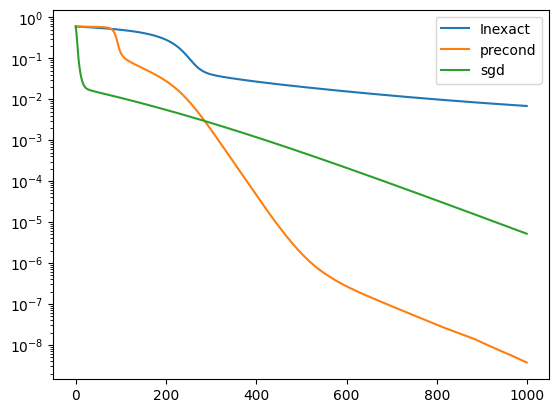

In [306]:
plt.semilogy(jnp.array(inexact_losses), label='Inexact')
plt.semilogy(jnp.array(precond_losses[0:len(inexact_losses)]), label='precond')
plt.semilogy(jnp.array(sgd_losses[0:len(inexact_losses)]), label='sgd')
plt.legend()